# Tokenization comes under the section of Data Preparation and Sampling

#Step1: Creating Tokens

#The print command prints the total number of characters followed by the first 100 characters of this file for illustration purposes.


In [82]:
import re
with open(r'The_Verdict.txt', 'r', encoding="utf-8", errors='ignore') as f:
    raw_text = f.read()

print("Total number of characters:", len(raw_text))
print(raw_text[:99])


Total number of characters: 21458

I HAD always thought Jack Gisburn rather a cheap genius-though a good fellow enough--so it was no 



#Our goal is to tokenize this 21458-character text short story into individual words and special characters that we can then turn into embeddings for LLM training.

#How can we best split this text to obtain a list of tokens? For this, we go on a small excursion and use python's regular


In [83]:
preprocessed = re.split(r'([!@#$%^&*_\[\]\-+=:;",<>/?.|{}\s]'')', raw_text)
preprocessed = [item.strip() for item in preprocessed if item.strip()]
print(preprocessed[:30])
print(len(preprocessed))

['I', 'HAD', 'always', 'thought', 'Jack', 'Gisburn', 'rather', 'a', 'cheap', 'genius', '-', 'though', 'a', 'good', 'fellow', 'enough', '-', '-', 'so', 'it', 'was', 'no', 'great', 'surprise', 'to', 'me', 'to', 'hear', 'that', ',']
4859


Now we are done with Tokenizing the short story. Now the next is converting tokens into token ID's

Note: The ID's are assigned individually to each word. Suppose if any word repeats many times in sentence of the story, but still the tokenised ID is considered only once. Ex: If 'the' appears 3 times even then in the tokenised list the word 'the' appears only once with a unique id after assigning id to it.

In [84]:
all_words = sorted(set(preprocessed))
vocab_size = len(all_words)

print(vocab_size)

1250


The number of words in vocabulary after we made all the words in preprocessed as a set. Here set takes only unique words. So the number of words reduces from
4859 ---> 1250

NOTE: Now we are going to assign the vocabulary with id. For this we are going to create a dictionary that assigns a unique value for each unique word. For assigning a unique value to each word sorted in alphabetical order we use enumerate function. Python has this function that takes each word from the all_words and assigns a unique number for each word.

In [85]:
vocab = {token:integer for integer,token in enumerate(all_words)}
print(vocab)

{'!': 0, '"': 1, "'": 2, "'Are": 3, "'It's": 4, "'coming'": 5, "'done'": 6, "'subject": 7, "'technique'": 8, "'way": 9, '(I': 10, '(Though': 11, '(including': 12, ')': 13, ',': 14, '-': 15, '.': 16, '0': 17, '1': 18, '20': 19, '21': 20, '22': 21, '4': 22, ':': 23, ';': 24, '?': 25, 'A': 26, 'Abigor': 27, 'About': 28, 'AdamBMorgan': 29, 'Ah': 30, 'Among': 31, 'And': 32, 'Arrt': 33, 'As': 34, 'At': 35, 'Attribution': 36, 'AzaToth': 37, 'Be': 38, 'Begin': 39, 'Bender235': 40, 'Blurpeace': 41, 'Boris23': 42, 'Bromskloss': 43, 'Burlington': 44, 'But': 45, 'By': 46, 'Carlo': 47, 'Chicago': 48, 'Claude': 49, 'Come': 50, 'Commons': 51, 'Creative': 52, 'Croft': 53, 'Croft)': 54, 'Dbenbenn': 55, 'Destroyed': 56, 'Devonshire': 57, 'Dha': 58, "Don't": 59, 'Dschwen': 60, 'Dubarry': 61, 'During': 62, 'Emperors': 63, 'FDL': 64, 'Florence': 65, 'For': 66, 'GNU': 67, 'Gallery': 68, 'Gideon': 69, 'Gisburn': 70, "Gisburn's": 71, 'Gisburns': 72, 'Grafton': 73, 'Greek': 74, 'Grindle': 75, "Grindle's": 76, 

In [86]:
for i, item in enumerate(vocab.items()):
  print(item)
  if i>=50:
    break

('!', 0)
('"', 1)
("'", 2)
("'Are", 3)
("'It's", 4)
("'coming'", 5)
("'done'", 6)
("'subject", 7)
("'technique'", 8)
("'way", 9)
('(I', 10)
('(Though', 11)
('(including', 12)
(')', 13)
(',', 14)
('-', 15)
('.', 16)
('0', 17)
('1', 18)
('20', 19)
('21', 20)
('22', 21)
('4', 22)
(':', 23)
(';', 24)
('?', 25)
('A', 26)
('Abigor', 27)
('About', 28)
('AdamBMorgan', 29)
('Ah', 30)
('Among', 31)
('And', 32)
('Arrt', 33)
('As', 34)
('At', 35)
('Attribution', 36)
('AzaToth', 37)
('Be', 38)
('Begin', 39)
('Bender235', 40)
('Blurpeace', 41)
('Boris23', 42)
('Bromskloss', 43)
('Burlington', 44)
('But', 45)
('By', 46)
('Carlo', 47)
('Chicago', 48)
('Claude', 49)
('Come', 50)


As we can see, based on the output above, the dictrinary contains individual tokens assiciated with unique integer labels. Now we consider this uniquely numbering each word as encoding. Next we would just have to exactly the opposite and that would be decoding. This is because ML gives output as number and you need to convert those back into words.

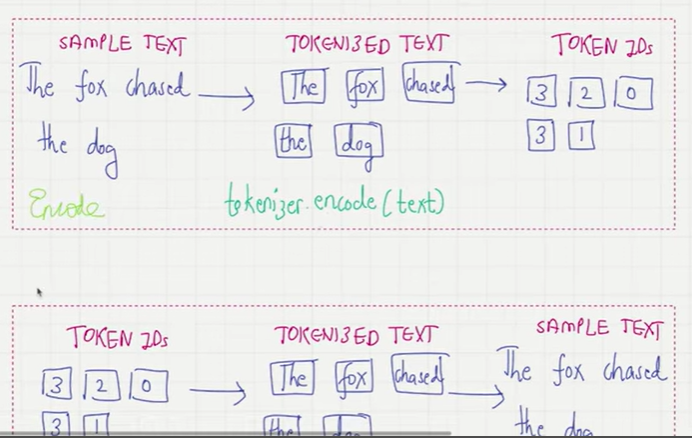

Let's implement a complete tokenizer class in Python.

The class will have an encode method that splits
text into tokens and carries out the string-to-integer mapping to produce token IDs via the
vocabulary.

In addition, we implement a decode method that carries out the reverse
integer-to-string mapping to convert the token IDs back into text.

Step 1: Store the vocabulary as a class attribute for access in the encode and decode methods
    
Step 2: Create an inverse vocabulary that maps token IDs back to the original text tokens

Step 3: Process input text into token IDs

Step 4: Convert token IDs back into text

Step 5: Replace spaces before the specified punctuation

In [96]:
class SimpleTokenizerV1:
  def __init__(self, vocab):
    self.str_to_int = vocab
    self.int_to_str = {i:s for s,i in vocab.items()}

  def encode(self, text):
    # Tokenize based on common word boundaries, keeping contractions like 'It's' together.
    # This regex splits by whitespace or punctuation not part of a word (e.g., '.', ',', '!', '?', etc.)
    preprocessed = re.split(r'(\s+|[.,!?;()"-])',text) # Fixed regex here
    preprocessed = [item.strip() for item in preprocessed if item.strip()]
    ids = [self.str_to_int[s] for s in preprocessed]
    return ids

  def decode(self, ids):
    text = " ".join([self.int_to_str[i] for i in ids])
    # Replace spaces before punctuation (the original requirement)
    text = re.sub(r'\s+([.,!?;)"\-])', r'\1', text)
    text = re.sub(r'\s+([.,!?;)"\-])', r'\1', text)
    text = re.sub(r'(["()])\s*', r'\1', text) # Remove space after opening quotes/parentheses
    return text

Let's instantiate a new tokenizer object from the SimpleTokenizerV1 class and tokenize a
passage from Edith Wharton's short story to try it out in practice:

In [97]:
tokenizer = SimpleTokenizerV1(vocab)
text = """"It's the last he painted, you know,"
           Mrs. Gisburn said with pardonable pride."""
ids = tokenizer.encode(text)
print(ids)

[1, 96, 1097, 689, 614, 844, 14, 1244, 683, 14, 1, 110, 16, 70, 958, 1225, 853, 896, 16]


In [98]:
tokenizer.decode(ids)

'"It\'s the last he painted, you know,"Mrs. Gisburn said with pardonable pride.'

Now lets try giving it a text that is not there in vocab.

NOTE: You get an error. This is why we need to train the model with a huge data or texts.

In [99]:
text1 = "Hello, so you like tea?"
print(tokenizer.encode(text1))

KeyError: 'Hello'

To deal with the above problem, tools like Chat GPT, Gemini use a special solution called SPECIAL CONTEXT TOKENS to deal with messages that has words that are missing


HERE WE WILL USE SimpleTokenizerV2 WHERE WE WILL HANDLE THE WORDS THAT ARE NOT AVAILABLE IN THE GIVEN DATA.

In this section, we will modify this tokenizer to handle unknown
words.


In particular, we will modify the vocabulary and tokenizer we implemented in the
previous section, SimpleTokenizerV2, to support two new tokens, <|unk|> and
<|endoftext|>

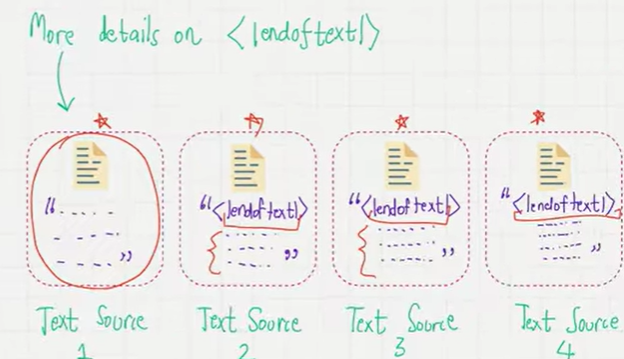

In [100]:
all_tokens = sorted(list(set(preprocessed)))
all_tokens.extend(["<|endoftext|>", "<|unk|>"])

vocab = {token:integer for integer, token in enumerate(all_tokens)}
print(len(vocab))

1252


In [101]:
for i, item in enumerate(list(vocab.items())[-5:]):
  print(item)

('younger', 1247)
('your', 1248)
('yourself', 1249)
('<|endoftext|>', 1250)
('<|unk|>', 1251)


In [110]:
class SimpleTokenizerV2:
  def __init__(self, vocab):
    self.str_to_int = vocab
    self.int_to_str = {i:s for s,i in vocab.items()}

  def encode(self, text):
    # Tokenize based on common word boundaries, keeping contractions like 'It's' together.
    # This regex splits by whitespace or punctuation not part of a word (e.g., '.', ',', '!', '?', etc.)
    preprocessed = re.split(r'(\s+|[.,!?;()"-])',text) # Fixed regex here
    preprocessed = [item.strip() for item in preprocessed if item.strip()]
    preprocessed = [item if item in self.str_to_int else "<|unk|>" for item in preprocessed]
    ids = [self.str_to_int[i] for i in preprocessed]
    return ids

  def decode(self, ids):
    text = " ".join([self.int_to_str[i] for i in ids])
    # Replace spaces before punctuation (the original requirement)
    text = re.sub(r'\s+([.,!?;)"\-])', r'\1', text)
    text = re.sub(r'\s+([.,!?;)"\-])', r'\1', text)
    text = re.sub(r'(["()])\s*', r'\1', text) # Remove space after opening quotes/parentheses
    return text

In [122]:
tokenizer1= SimpleTokenizerV2(vocab)

text1 = "Hello, do you like tea?"
text2 = "In the sunlit terraces of the palace."

text3 = " <|endoftext|> ".join((text1, text2))
print(text3)

Hello, do you like tea? <|endoftext|> In the sunlit terraces of the palace.


In [123]:
tokenizer1.encode(text3)

[1251,
 14,
 434,
 1244,
 718,
 1084,
 25,
 1250,
 93,
 1097,
 1066,
 1093,
 818,
 1097,
 1251,
 16]

In [124]:
tokenizer1.decode(tokenizer1.encode(text3))

'<|unk|>, do you like tea? <|endoftext|> In the sunlit terraces of the <|unk|>.'